In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Import your modular classes
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import DataLoader
from src.sentiment import SentimentAnalyzer
from src.analysis import FinancialAnalyzer

# 1. Load News Data
# (Replace with your actual path)
news_loader = DataLoader('../src/raw_analyst_ratings.csv') 
news_df = news_loader.load_data()

In [4]:
import yfinance as yf

# 1. Fetch the stock data to define 'stock_df'
print("Fetching Stock Data...")
stock_df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

# Check if it loaded correctly
print(f"Stock data loaded: {len(stock_df)} rows")

Fetching Stock Data...


C:\Users\Her\AppData\Local\Temp\ipykernel_36788\940632203.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

Stock data loaded: 1006 rows


In [2]:
# 2. Apply Sentiment Analysis
print("Running Sentiment Analysis...")
sentiment_analyzer = SentimentAnalyzer(news_df, text_column='headline')
news_df = sentiment_analyzer.apply_sentiment_analysis()

Running Sentiment Analysis...


In [3]:
# 3. Load Stock Data (Example: AAPL)
print("Fetching Stock Data...")
# Note: Ensure the date range matches your news data
stock_df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

Fetching Stock Data...


C:\Users\Her\AppData\Local\Temp\ipykernel_15044\2589878196.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [5]:
# 4. Perform Correlation Analysis
analyzer = FinancialAnalyzer(stock_df, news_df)
correlation_score, merged_data = analyzer.correlation_analysis()

print(f"Pearson Correlation Coefficient: {correlation_score:.4f}")

Pearson Correlation Coefficient: 0.0507


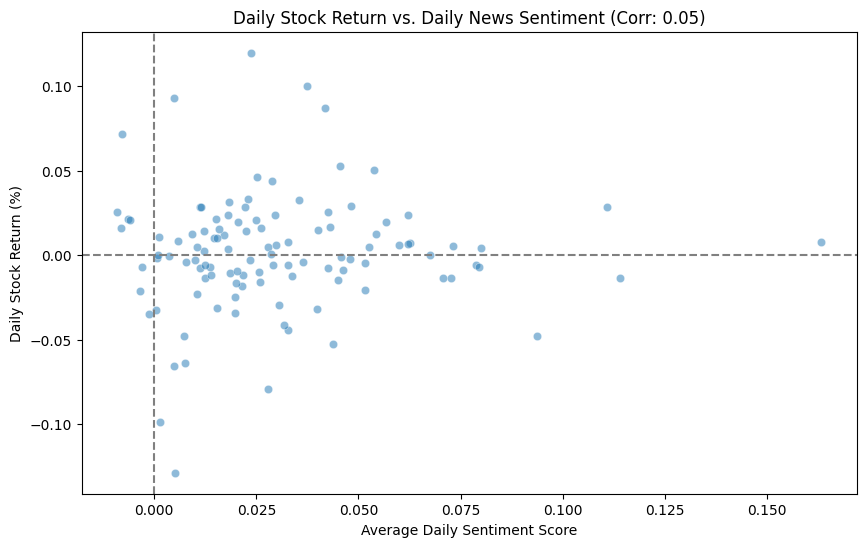

In [6]:
# 5. Visualizing the Correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sentiment_score', y='Daily_Return', data=merged_data, alpha=0.5)
plt.title(f'Daily Stock Return vs. Daily News Sentiment (Corr: {correlation_score:.2f})')
plt.xlabel('Average Daily Sentiment Score')
plt.ylabel('Daily Stock Return (%)')
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.show()